[질의응답 링크](https://docs.google.com/spreadsheets/d/1k5FHLcbLIRJDJfrRli3hBqspysIGrYlrzLH918TxiBY/edit?usp=sharing) 클릭하여 접속

## **1. 넷플릭스 데이터셋 파악하기**

### **캐글의 넷플릭스 데이터셋을 다운로드**
* [캐글 사이트 넷플릭스 링크](https://www.kaggle.com/datasets/shivamb/netflix-shows)
* [넷플릭스 데이터셋의 변수 설명]
    * show_id: 각 쇼의 고유 ID (쇼를 식별할 수 있는 고유한 번호)
    * type: 쇼의 카테고리 (영화 또는 TV 쇼)
    * title: 쇼의 이름
    * director: 쇼의 감독 이름
    * cast: 배우의 이름 및 쇼의 다른 출연진
    * country: Netflix에서 프로그램을 시청할 수 있는 국가의 이름
    * date_added: Netflix에 프로그램이 추가된 날짜
    * release_year: 쇼의 출시 연도
    * rating: 넷플릭스 등급 (관람 등급, 예: G, PG, TV-MA 등)
    * duration: 쇼의 지속 시간 (영화는 시간, TV 쇼는 시즌 및 에피소드 수로 표현)
    * listed_in: 쇼의 장르 (예: 액션, 드라마, 코미디 등)
    * description: 쇼를 설명하는 일부 텍스트 (쇼의 줄거리 또는 개요)

#### **데이터 분석 라이브러리 불러오기**
*   Pandas, Numpy, Matplotlib, Seaborn

In [1]:
# numpy 로드하여 np로 사용
# pandas 로드하여 pd로 사용
# matplotlib.pyplot 로드하여 plt로 사용
# seaborn 로드하여 sns로 사용
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

#### **csv 파일 불러오기**
##### `pd.read_csv("")` 코드의 큰 따옴표 안에 `경로 붙여넣기`

In [ ]:
# 세션 저장소에 업로드한 csv 파일을 읽어 변수에 할당
# csv 파일 읽어오기
netflix = pd.read_csv('data/netflix_titles.csv')
netflix.shape

#### **데이터 내용 확인**
- `.columns` : 컬럼명 확인
- `.head(3)` : 데이터의 상단 3개 행 출력
- `.info()` : 데이터에 대한 전반적인 정보 제공
> - 행과 열의 크기
> - 컬럼명
> - 컬럼별 결측치
> - 컬럼별 데이터 타입

In [3]:
# .columns : 열 이름 확인
netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [4]:
# .head(3) : 데이터 처음 3개의 행 출력
netflix.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [5]:
# .info() : 열에 대한 요약 정보 확인
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## **2. 넷플릭스 데이터셋 결측치 처리하기**

### **결측치란?**
* 데이터에 값이 없거나 부적절한 경우 결측치로 표시함
* NA : Not Available ( 유효하지 않은 )
* NaN : Not a Number ( 숫자가 아닌 )
* Null : 아뭇것도 존재하지 않음을 의미함 



### **결측치 처리하는 방법**
* 방법1 : 결측치가 있는 행 또는 열을 **제거**하기
    * 데이터 손실 ( 표본 크기의 축소 ) 발생
* 방법2 : 결측치를 다른 값을 **치환**하기
    * 데이터 특성에 맞게 평균,중앙값,최빈값 등으로 대체 가능
    * 다른 변수와 상관관계가 있을 경우, 알맞은 값을 넣어줄 수 있음
    * 도메일 지식이 있는 경우 효율적인 방법법
* 방법3 : 예측하는 모델을 사용하여 결측치를 대체하기 ( 모델 기반 처리)
    * 예측 모델 또는 특성에 맞는 모델을 사용하여 결측치 처리

### **넷플릭스 결측치 비율 확인하기**
* 결측치가 차지하는 비율에 따라 다르게 처리하기
    * **결측치가 데이터의 5% 미만**
        * 일부분에만 결측치가 존재하므로 결측치가 있는 행을 삭제하는 것이 적합합니다. 데이터 손실이 최소화되면, 분석의 신뢰성에 큰 영향을 미치지 않습니다. 
    * **결측치가 데이터의 5%에서 20% 사이** 
        * 결측치가 꽤 많은 상태이므로 삭제보다는 대체하는 하는 방법이 더 적합합니다. 평균,중간값,최빈값 등을 사용해 대체하거나, 필요에 따를 모델 기반 처리도 고려할 수 있습니다.
    *  **결측치가 데이터의 20% 이상**
        * 결측치가 너무 많은 상태이므로 결측치가 있는 열 전체를 제거하는 것이 권장되지만,데이터 손실이 크기 때문에 신중한 판단이 필요합니다.
        * 특히 데이터셋이 작거나 해당 변수가 중요한 역할을 할 때는 모델 기반 대체나 예측 모델을 통해 결측치를 보완하는 것이 더 적합할 수 있습니다. 
        * 따라서, 결측치가 20% 이상이라도 변수의 중요성,분석 목적,데이터량을 종합적으로 고려해 열을 제거할지, 대체할지를 결정하는 것이 중요합니다.
* 이러한 기준을 이론적인 가이드라인일 뿐, 절대적인 규칙은 아닙니다.        

#### **[파이썬 기초 문법] for문을 이용한 리스트 반복문**

In [6]:
# 목표: myList 변수에 국가명이 담긴 리스트를 넣고 반복문으로 출력

# myList는 '반복할 수 있는 것'으로 내부적으로 여러 개의 요소를 포함하고 있으며,
#           요소의 개수만큼 하나씩 순회
# a는 '반복자'로 myList에서 하나씩 꺼낸 요소를 저장하는 반복 변수
myList = ['Korea', 'USA', 'Japan']

for a in myList:
  print(a)

Korea
USA
Japan


#### **[파이썬 기초 문법] 문자열 포맷팅**
* 문자열 안에 어떤 값을 삽입하는 방법

In [7]:
# 목표: format() 함수를 이용한 문자열 포맷팅 수행

# { } 안에 숫자 대입
# format 함수 안에 넣을 숫자 삽입
print("나는 {}호선을 타고 다녀.".format(6))
print("나는 {}호선과 {}호선을 타고 다녀.".format(6, 4))

나는 6호선을 타고 다녀.
나는 6호선과 4호선을 타고 다녀.


#### **for문으로 결측치 비율 확인하기**
* 결측치 비율 확인하고 처리하기
    * .isna().sum()
        * .isna()에서 결측치는 True 반환, 그 외에는 False 반환
        * .isna().sum() 은 각 열의 결측치 개수 반환
        * DataFrame내에서 결측치 개수 반환

In [6]:
print("\n결측치 확인:")
print(netflix.isnull().sum())


결측치 확인:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [7]:
# for 반복문을 통해 각 컬럼별 결측치 비율을 계산하여 문자열로 출력

# for i in netflix.columns : 각 열에 대해 반복

# netflix[i].isna().sum() : netflix 데이터 열(column)의 결측치 개수의 합
# .isna( ) : 결측 값은 True 반환, 그 외에는 False 반환
# len(netflix) : netflix 데이터 행(row) 개수
# * 100 : 결측치 비율인 0.xx 를 보기 쉽게 표현하기 위해

# if missingValueRate > 0 : 결측치가 있을 때 실행

# 열 이름과 결측치 비율 출력
# "문자열".format() : 문자열 포맷팅 기법으로 `{ }`에 차례대로 매핑
#                     `{0}`에는 i 매핑, `{1}`에는 round(missingValueRate, 2) 매핑
# round(missingValueRate, 2) : 소수점 2자리까지 반올림

for i in netflix.columns :
    missingValueRate = netflix[i].isna().sum() / len(netflix) * 100
    if missingValueRate > 0 :
        print("{} null rate: {}%".format(i,round(missingValueRate, 2)))

director null rate: 29.91%
cast null rate: 9.37%
country null rate: 9.44%
date_added null rate: 0.11%
rating null rate: 0.05%
duration null rate: 0.03%


In [8]:
# netflix.columns의 결과는 Pandas의 Index 객체이며,
# 파이썬의 리스트처럼 for 문에서 요소를 하나씩 꺼내 사용!
netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

#### **결측치 비율에 따른 처리 방법**
* 결측치 비율이 20% 이상인 director 컬럼은 결측치를 대체하는 방식으로 처리
* 결측치 비율이 country(5% ~ 20%) 컬럼과 cast(9.44%)은 결측치 대체로 처리
* 결측치 비율이 5% 미만인 date_add(0.11%), rating(0.05%), duration(0.03%) 결측치 비율이 낮기 때문에 결측치가 있는 행을 삭제로 처리
* 결측치 처리하는 함수
    * fillna() - 결측치를 특정값을 채우거나 대체하여 처리
    * repace(np.nan,'문자') - 결측치를 문자열 바꾸기 함수로 처리하기, np.nan은 결측치를 의미한다.
    * dropna(axis=0) - 결측치가 존재하는 행 전체 제거거

#### **fillna( ) 함수로 결측치를 다른 값으로 대체하기**

In [17]:
# .fillna( ) : 결측치를 다른 값으로 대체하여 처리
# 결측치 비율 : country(9.44%)
netflix['country'] = netflix['country'].fillna('No Data')

In [18]:
netflix['country'].value_counts().head()

country
United States     2809
India              972
United Kingdom     418
Japan              243
South Korea        199
Name: count, dtype: int64

#### **replace( ) 함수로 결측치를 다른 값으로 대체하기**

In [19]:
# .replace(np.nan, 'b') : 결측치를 문자열 바꾸기 함수를 통해 처리
# 결측치 비율 : director(29.91%), cast(9.37%)
netflix['director'] = netflix['director'].replace(np.nan, 'No Data')
netflix['cast'] = netflix['cast'].replace(np.nan, 'No Data')

In [20]:
netflix['director'].value_counts()

director
No Data                   2214
Raúl Campos, Jan Suter      18
Marcus Raboy                15
Jay Karas                   14
Cathy Garcia-Molina         13
                          ... 
Anubhav Sinha                1
Maha Venkatesh               1
Tharun Bhascker              1
Farhan Alam                  1
Mozez Singh                  1
Name: count, Length: 4286, dtype: int64

#### **dropna( )로 결측치를 가진 행 제거하기**
- `.dropna(axis = 0)` : 결측치가 있는 행 전체 제거
- `.dropna(axis = 1)` : 결측치가 있는 열 전체 제거
- inplace=True 이므로 블라블라된다

In [21]:
netflix.shape

(7961, 12)

In [22]:
# .dropna(axis = 0) : 결측치가 있는 행 전체 제거
# 원본 객체를 수정하려면 inplace = True 옵션 추가
# 결측치 비율 : date_added(0.11%), rating(0.05%), duration(0.03%)
netflix.dropna(axis = 0, inplace=True)
print(netflix.shape)

(7961, 12)


#### **처리된 결측치 확인 - info( )**

In [23]:
# .info() : 열에 대한 요약 정보 확인
# 8807 rows(원본 데이터 행 개수) - 17 rows(결측치 행) = 8790 rows(결측치가 제거된 행 개수)
netflix.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7961 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7961 non-null   object
 1   type          7961 non-null   object
 2   title         7961 non-null   object
 3   director      7961 non-null   object
 4   cast          7961 non-null   object
 5   country       7961 non-null   object
 6   date_added    7961 non-null   object
 7   release_year  7961 non-null   int64 
 8   rating        7961 non-null   object
 9   duration      7961 non-null   object
 10  listed_in     7961 non-null   object
 11  description   7961 non-null   object
dtypes: int64(1), object(11)
memory usage: 808.5+ KB


#### **처리된 결측치 확인 - .isna( ).sum( )**

In [24]:
# 데이터프레임의 각 컬럼별 결측치 개수 반환
# isna() == isnull() : 결측 값은 True 반환하고, 그 외에는 False 반환
netflix.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## **3. 넷플릭스 피처 엔지니어링하기**

#### **[파이썬 기초 문법] 딕셔너리**
- 딕셔너리는 중괄호 { }로 선언하며, 'key : value' 형태를 쉼표(,)로 연결하여 생성
- 일반적으로 key는 문자열을 사용
- { key1 : value1, key2 : value2, ... key_n : value_n }

In [25]:
# 파이썬 딕셔너리 생성
grade_dic = {
    "A" : 100,
    "B" : 90,
    "C" : 80
}
print(grade_dic)

{'A': 100, 'B': 90, 'C': 80}


#### **[파이썬 문법] 판다스의 데이터프레임**
* 데이터프레임은 행과 열로 만들어지는 2차원 배열의 형태
* 파이썬 딕셔너리로 데이터프레임 생성 가능!

In [26]:
# 판다스 데이터프레임 생성
person = pd.DataFrame({
    "name" : ["Selena", "Seungwoo", "Louis"],
    "job" : ["Data Scientist", "Chef", "Home Protector"],
    "grade" : ["A", "B", "C"]
})
print(person)

       name             job grade
0    Selena  Data Scientist     A
1  Seungwoo            Chef     B
2     Louis  Home Protector     C


#### **[파이썬 기초 문법] map 함수**
* 기존 값에서 새로운 값으로 변환할 때 (예: 등급을 점수로 변환)

In [27]:
# 목표: map 함수 이용하여 grade 열의 값을 점수로 변환하기
person['grade'] = person['grade'].map(grade_dic)
print(person)

       name             job  grade
0    Selena  Data Scientist    100
1  Seungwoo            Chef     90
2     Louis  Home Protector     80


### **넷플릭스 시청 등급 변수 생성하기**
* Feature Engineering - 기존에 존재하는 변수를 활용하여 새로운 정보를 추가로 생성하는 과정
* 시청 등급 설명표를 참고하여 Netflix의 rating 변수를 이용한 age_group(시청 등급) 정보를 변수로 생성

- `.map( )` : 사전에 정의한 내용을 변수에 적용

- [넷플릭스 시청 등급 설명표](https://www.primevideo.com/help/ref=atv_hp_nd_cnt?nodeId=GFGQU3WYEG6FSJFJ)

In [29]:
netflix['rating']

0       PG-13
1       TV-MA
4       TV-MA
7       TV-MA
8       TV-14
        ...  
8801    TV-MA
8802        R
8804        R
8805       PG
8806    TV-14
Name: rating, Length: 7961, dtype: object

In [30]:
# 시청 등급 기준표를 참고하여 Netflix의 rating 변수를 이용한 age_group_dic 변수 생성
# rating 컬럼의 값을 age_group이라는 새로운 컬럼으로 복사
netflix['age_group'] = netflix['rating']

# 시청 등급 코드를 더 이해하기 쉬운 표현으로 매핑할 딕셔너리 정의(key, value 선언)
age_group_dic = {
    'G': 'All',
    'TV-G': 'All',
    'TV-Y': 'All',
    'PG': 'Older Kids',
    'TV-Y7': 'Older Kids',
    'TV-Y7-FV': 'Older Kids',
    'TV-PG': 'Older Kids',
    'PG-13': 'Teens',
    'TV-14': 'Young Adults',
    'NC-17': 'Adults',
    'NR': 'Adults',
    'UR': 'Adults',
    'R': 'Adults',
    'TV-MA': 'Adults'
    }

# map 함수를 이용하여 rating 컬럼의 값을 딕셔너리를 기반으로 변환하여 age_group 컬럼에 저장
# .map( ) : 사전에 정의한 내용을 변수에 적용
netflix['age_group'] = netflix['age_group'].map(age_group_dic)
netflix.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,age_group
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,No Data,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Teens
1,s2,TV Show,Blood & Water,No Data,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Adults


In [31]:
netflix['age_group'].value_counts()

age_group
Adults          3802
Young Adults    1927
Older Kids      1292
Teens            482
All              458
Name: count, dtype: int64

## **4. 넷플릭스 시각화하기**
### **넷플릭스 색상 시각화하기**
* sns.palplot([`색상RBG`]) : 색상 확인하는 함수
* plt.title() : 그래프의 타이틀 설정
* plt.show() : 화면에 표시하는 기능을 하며, Jupyter를 사용할 때는 자동으로 표시되기 때문에 호출할 필요가 없음(하지만, 쓰는 걸 권장)

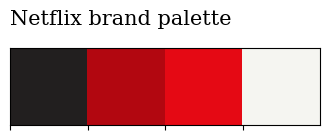

In [32]:
# 넷플릭스 브랜드 상징 색깔 시각화
sns.palplot(['#221f1f', '#b20710', '#e50914', '#f5f5f1'])

# 제목 정하기
plt.title('Netflix brand palette', loc='left', fontfamily='serif', fontsize=15, y=1.2)
plt.show()

### **넷플릭스 오징어 게임 검색하기**
* Squid Game(오징어 게임) 검색 조건
* str.contains() : 지정한 문자열이 포함되어 있으면 True 반환, 그 외에는 False 반환
    * na = False : 값이 NA일 경우, False로 처리
    * case = False : 대소문자를 구분하지 않고 검색


In [35]:
print(type(netflix['title']))
print(type(netflix['title']).str)


<class 'pandas.core.series.Series'>
<class 'pandas.core.strings.accessor.StringMethods'>


In [41]:
netflix['title'].str.contains('squid game', na=False, case=False)

0       False
1       False
4       False
7       False
8       False
        ...  
8801    False
8802    False
8804    False
8805    False
8806    False
Name: title, Length: 7961, dtype: bool

In [42]:
# 오징어 게임을 검색한 조건을 넷플릭스 데이터에 넣어서 True인 값만 출력
netflix[netflix['title'].str.contains('Squid Game', na=False, case=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,age_group


In [43]:
netflix.loc[netflix['title'].str.contains('Squid Game', na=False, case=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,age_group


### **넷플릭스 파이 차트 그리기**
* 넷플릭스 파이 차트 그리기
    * plt.pie() - Pie Plot 시각화
        * labels : 부채꼴 조각 이름
        * autopct : 부채꼴 안에 표기될 숫자 형식 지정
            * 문자열 % 포맷팅으로 %0.f 형태는 소수점 없이 정수처럼 인식
            * 진짜 %를 표시하기 위해 %% 로 작성
        * startangle : 부채꼴이 그려지는 시작 각도 설정, 90이면 12시 방향
        * explode : 부채꼴이 Pie Plt의 중심에서 벗어나는 정도 설정
        * shadow : 그림자 효과 표시
    * plt.subtitle() : 전체 Plot의 제목
    * plt.title() : 서브 Plot의 제목
    *             

In [44]:
# Movies & TV shows의 각각 value_counts 출력
# .value_counts() : 값의 개수 출력
type_counts = netflix['type'].value_counts()
print(type_counts)
print(type_counts.index)

type
Movie      5687
TV Show    2274
Name: count, dtype: int64


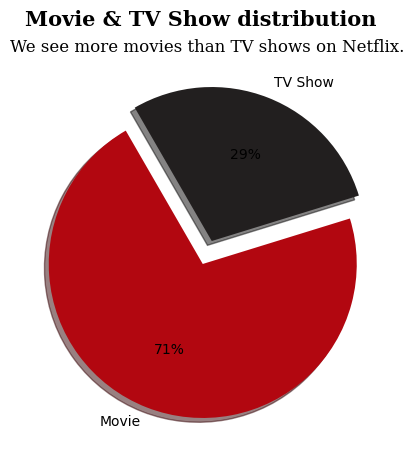

In [45]:
# 5 x 5 크기의 플롯 만들기
# Figure 크기 설정 및 배경색 설정
fig = plt.figure(figsize=(5, 5))

# pie plot 통해 Movies & TV shows 각각 비율 시각화
# plt.pie의 매개변수 설명
# labels : 부채꼴 조각 이름
# autopct : 부채꼴 안에 표시될 숫자 형식 지정
#           문자열에서 % 포맷팅으로 %0.f 형태로 사용하면 소수점 없이 정수처럼 인식
#           진짜 %를 표시하기 위해 %%로 작성
# startangle : 부채꼴이 그려지는 시작 각도 설정, 90이면 12시 방향
# explode : 부채꼴이 파이 플롯의 중심에서 벗어나는 정도 설정
# shadow : 그림자 효과 표시
plt.pie(type_counts, labels=type_counts.index, autopct='%0.f%%', startangle=120,
        explode=[0.08, 0.08], shadow=True, colors=['#b20710', '#221f1f'])

plt.suptitle('Movie & TV Show distribution', fontfamily='serif', fontsize=15, fontweight='bold')
plt.title('We see more movies than TV shows on Netflix.', fontfamily='serif', fontsize=12)
plt.show()

### **넷플릭스 워드 클라우드**
* 워드 클라우드란 텍스트 데이터의 빈도나 중요도를 이용하여 데이터를 시각화하는 방법
    * 중요한 것을 진한 색이나 크기를 크게 하여 만드는 것이 일반적

* from wordcloud import WordCloud 
    * 워드 클라우드 생성 역할을 하는 클래스
* from PIL import Image  
    * 워드 클라우드를 원하는 형태로 그리기 위해 Image를 불러오는 패키지
* WordCloud().gnerate(text) : 선언해준 text에서 wordcloud를 생성
    * text 변환 - wordcloud에서 작동할 수 있도록 DataFrame을 list로 1차 변환시키고, str(문자열)로 2차 변환
    * mask : 단어를 그릴 위치, 흰색(#FFFF) 항목은 Masking 된 것으로 간주함
* plt.matplotlib.colors.LinearSegmentedColormap.from_list()
    * 컬러맵 생성    
* plt.imshow()
    * array에 색을 채워서 Image로 표시함
* plt.axis('off')
    * 축(axis) 삭제    

#### wordcloud 설치

In [46]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [47]:
# 넷플릭스 데이터의 description 열 이용한 워드 클라우드 생성

# from wordcloud import WordCloud : 워드 클라우드 생성에 필요한 모듈
# from PIL import Image : 워드 클라우드를 원하는 형태로 그리기 위해 그림을 불러오는 패키지
from wordcloud import WordCloud
from PIL import Image

plt.figure(figsize=(15, 5))

# wordcolud에서 작동할 수 있도록 데이터프레임을 list로 1차 변환시키고
# str(문자열)로 2차 변환
text = str(list(netflix['description']))
text

'[\'As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.\', \'After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.\', \'In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.\', \'On a photo shoot in Ghana, an American model slips back in time, becomes enslaved on a plantation and bears witness to the agony of her ancestral past.\', "A talented batch of amateur bakers face off in a 10-week competition, whipping up their best dishes in the hopes of being named the U.K.\'s best.", "A woman adjusting to life after a loss contends with a feisty bird that\'s taken over her garden — and a husband who\'s struggling to find a way forward.", \'After most of her family is murdered in a terrorist bombing, a y

<Figure size 1500x500 with 0 Axes>

In [48]:


# mask : 단어를 그릴 위치 설정, 흰색(#FFFFFF) 항목은 마스킹된 것으로 간주
# 로고 이미지 열고 넘파이 배열로 변환
mask = np.array(Image.open('data/netflix_logo.jpg'))
mask

array([[[243,  44,  51],
        [243,  44,  51],
        [243,  44,  51],
        ...,
        [255,  35,  47],
        [237,  42,  48],
        [228,  75,  77]],

       [[216,  12,  21],
        [216,  12,  21],
        [216,  12,  21],
        ...,
        [223,  14,  20],
        [197,  31,  31],
        [255, 134, 131]],

       [[222,  12,  23],
        [222,  12,  23],
        [222,  12,  23],
        ...,
        [193,  18,  23],
        [190,  62,  59],
        [255, 221, 211]],

       ...,

       [[228,  19,  25],
        [224,  19,  26],
        [217,  18,  23],
        ...,
        [176,  19,  26],
        [188,  52,  56],
        [255, 192, 193]],

       [[190,  14,  16],
        [192,  22,  22],
        [190,  31,  28],
        ...,
        [212,  26,  39],
        [199,  32,  42],
        [255, 123, 133]],

       [[236,  61,  68],
        [248,  79,  84],
        [255, 104, 107],
        ...,
        [255,  79,  91],
        [237,  55,  67],
        [255,  93, 102]]

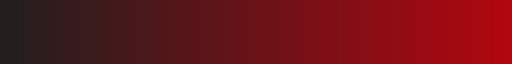

In [49]:

# 워드 클라우드 색상맵 만들기
cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list('', ['#221f1f','#b20710'])
cmap

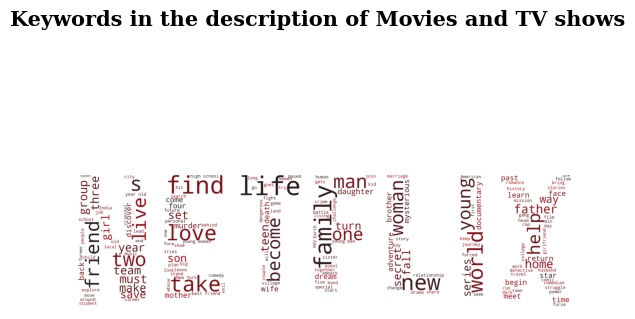

In [50]:

# 워드 클라우드 생성
# WordCloud( ).generate(text) : 선언해준 text에서 wordcloud를 생성
wordcloud = WordCloud(background_color = 'white', width = 1400, height = 1400,
                      max_words = 170, mask = mask, colormap=cmap).generate(text)

plt.suptitle('Keywords in the description of Movies and TV shows',
             fontweight='bold', fontfamily='serif', fontsize=15)

# 워드 클라우드 표시
# plt.imshow( ) : array에 색을 채워서 이미지로 표시
plt.imshow(wordcloud)

# 축 감추기
plt.axis('off')
plt.show()

In [55]:
from wordcloud import WordCloud
from PIL import Image

plt.figure(figsize=(15, 5))

# wordcolud에서 작동할 수 있도록 데이터프레임을 list로 1차 변환시키고
# str(문자열)로 2차 변환
text = str(list(netflix['description']))
text

'[\'As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive and comical ways to help them both face the inevitable.\', \'After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swimming star is her sister who was abducted at birth.\', \'In a city of coaching centers known to train India’s finest collegiate minds, an earnest but unexceptional student and his friends navigate campus life.\', \'On a photo shoot in Ghana, an American model slips back in time, becomes enslaved on a plantation and bears witness to the agony of her ancestral past.\', "A talented batch of amateur bakers face off in a 10-week competition, whipping up their best dishes in the hopes of being named the U.K.\'s best.", "A woman adjusting to life after a loss contends with a feisty bird that\'s taken over her garden — and a husband who\'s struggling to find a way forward.", \'After most of her family is murdered in a terrorist bombing, a y

<Figure size 1500x500 with 0 Axes>

In [56]:
mask = np.array(Image.open('data/netflix_logo.jpg'))
mask

array([[[243,  44,  51],
        [243,  44,  51],
        [243,  44,  51],
        ...,
        [255,  35,  47],
        [237,  42,  48],
        [228,  75,  77]],

       [[216,  12,  21],
        [216,  12,  21],
        [216,  12,  21],
        ...,
        [223,  14,  20],
        [197,  31,  31],
        [255, 134, 131]],

       [[222,  12,  23],
        [222,  12,  23],
        [222,  12,  23],
        ...,
        [193,  18,  23],
        [190,  62,  59],
        [255, 221, 211]],

       ...,

       [[228,  19,  25],
        [224,  19,  26],
        [217,  18,  23],
        ...,
        [176,  19,  26],
        [188,  52,  56],
        [255, 192, 193]],

       [[190,  14,  16],
        [192,  22,  22],
        [190,  31,  28],
        ...,
        [212,  26,  39],
        [199,  32,  42],
        [255, 123, 133]],

       [[236,  61,  68],
        [248,  79,  84],
        [255, 104, 107],
        ...,
        [255,  79,  91],
        [237,  55,  67],
        [255,  93, 102]]

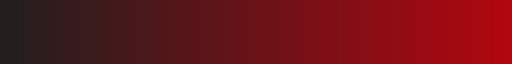

In [57]:
cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list('', ['#221f1f','#b20710'])
cmap

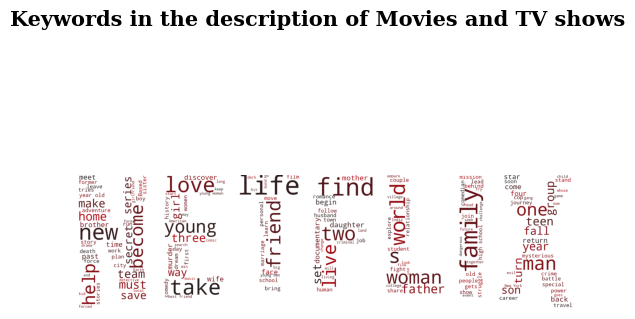

In [58]:

wordcloud = WordCloud(background_color = 'white', width = 1400, height = 1400,
                      max_words = 170, mask = mask, colormap=cmap).generate(text)

plt.suptitle('Keywords in the description of Movies and TV shows',
             fontweight='bold', fontfamily='serif', fontsize=15)

# 워드 클라우드 표시
# plt.imshow( ) : array에 색을 채워서 이미지로 표시
plt.imshow(wordcloud)

# 축 감추기
plt.axis('off')
plt.show()

### 넷플릭스 장르 분포 Bar Plot
* 장르 분리 및 개별 장르 카운트


In [59]:
netflix['listed_in'].value_counts()

listed_in
Documentaries                                                       343
Dramas, International Movies                                        337
Stand-Up Comedy                                                     303
Comedies, Dramas, International Movies                              260
Dramas, Independent Movies, International Movies                    243
                                                                   ... 
British TV Shows, Docuseries, TV Comedies                             1
TV Comedies, TV Dramas, TV Mysteries                                  1
Crime TV Shows, TV Comedies, Teen TV Shows                            1
Children & Family Movies, Faith & Spirituality, Music & Musicals      1
Cult Movies, Dramas, Thrillers                                        1
Name: count, Length: 497, dtype: int64

In [64]:
# 장르 분리 및 개별 장르 카운트
genre_series = netflix['listed_in'].str.split(', ').explode()
genre_series.value_counts()

listed_in
International Movies            2543
Dramas                          2316
Comedies                        1580
International TV Shows          1126
Action & Adventure               817
Documentaries                    794
Independent Movies               745
TV Dramas                        662
Romantic Movies                  588
Thrillers                        549
Children & Family Movies         535
TV Comedies                      493
Crime TV Shows                   420
Kids' TV                         368
Horror Movies                    340
Docuseries                       329
Music & Musicals                 328
Stand-Up Comedy                  311
Romantic TV Shows                299
Sci-Fi & Fantasy                 242
British TV Shows                 236
Reality TV                       205
Sports Movies                    201
Anime Series                     152
TV Action & Adventure            152
Spanish-Language TV Shows        144
Korean TV Shows             

In [ ]:
# Series 객체에서 reset_index() 함수를 호출하면  index의 값이 컬럼이 되므로 DataFrame 객체로 변경된다.
genre_counts = genre_series.value_counts().reset_index()
genre_counts.head(3)

,listed_in,count
0,International Movies,2543
1,Dramas,2316
2,Comedies,1580


In [65]:
# listed_in 컬럼명이 genre 로 변경됨
genre_counts.columns = ['genre', 'count']
genre_counts.head(3)

,genre,count
0,International Movies,2543
1,Dramas,2316
2,Comedies,1580


In [66]:
font_path = 'C:\\windows\\Fonts\\malgun.ttf'
#font의 파일정보로 font name 을 알아내기
font_prop = fm.FontProperties(fname=font_path).get_name()
print(font_prop)
matplotlib.rc('font', family=font_prop)

Malgun Gothic


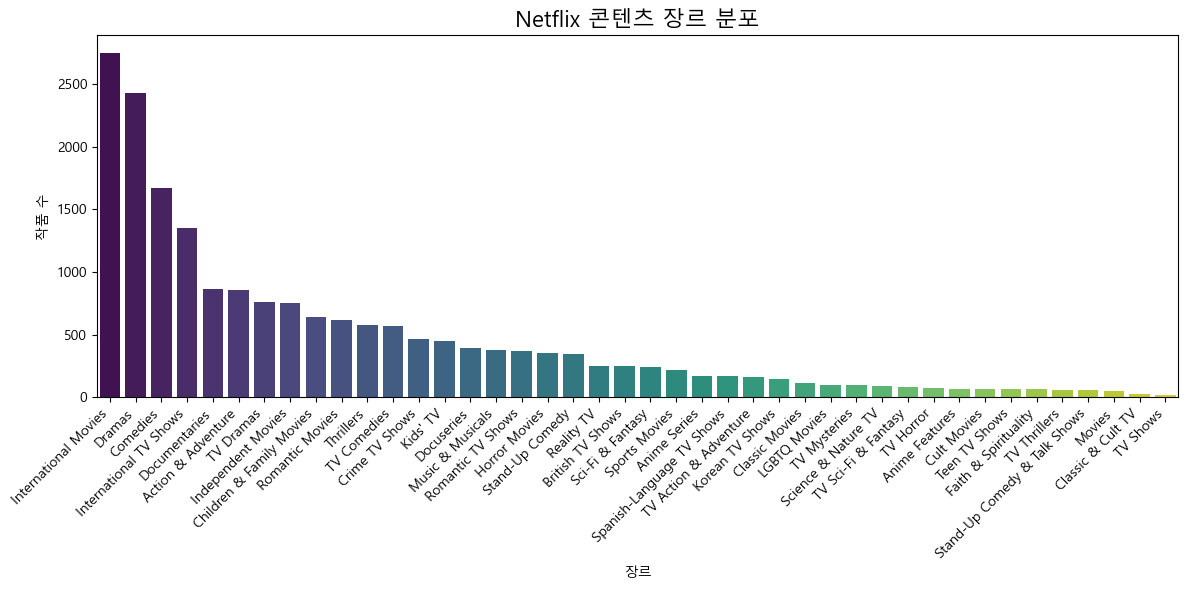

In [39]:

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(
    data=genre_counts,
    x='genre', y='count',
    hue='genre', palette='viridis',
    legend=False
)

plt.xticks(rotation=45, ha='right')
plt.title('Netflix 콘텐츠 장르 분포', fontsize=16)
plt.xlabel('장르')
plt.ylabel('작품 수')
plt.tight_layout()
plt.show()

### 인기 배우 TOP N 추출


In [67]:
# 배우 분리 (explode)
cast_series = netflix['cast'].str.split(', ').explode()
cast_series

0                     No Data
1                  Ama Qamata
1                 Khosi Ngema
1               Gail Mabalane
1              Thabang Molaba
                ...          
8806         Manish Chaudhary
8806             Meghna Malik
8806            Malkeet Rauni
8806           Anita Shabdish
8806    Chittaranjan Tripathy
Name: cast, Length: 59791, dtype: object

In [68]:
# 'No Data'는 따로 카운트해서 확인만 하고 싶다면
no_data_count = (cast_series == 'No Data').sum()
print(f"'No Data' 카운트: {no_data_count}")

'No Data' 카운트: 671


In [70]:
# 'No Data' 제거
cast_series_data = cast_series[cast_series != 'No Data']
cast_series_data.value_counts().reset_index().head(10)

,cast,count
0,Anupam Kher,43
1,Shah Rukh Khan,34
2,Naseeruddin Shah,31
3,Om Puri,30
4,Akshay Kumar,30
5,Takahiro Sakurai,29
6,Paresh Rawal,28
7,Yuki Kaji,28
8,Amitabh Bachchan,28
9,Boman Irani,27


In [71]:

# 상위 10명 배우 추출
top_actors = cast_series_data.value_counts().head(10).reset_index()
top_actors.columns = ['actor', 'count']
top_actors

,actor,count
0,Anupam Kher,43
1,Shah Rukh Khan,34
2,Naseeruddin Shah,31
3,Om Puri,30
4,Akshay Kumar,30
5,Takahiro Sakurai,29
6,Paresh Rawal,28
7,Yuki Kaji,28
8,Amitabh Bachchan,28
9,Boman Irani,27


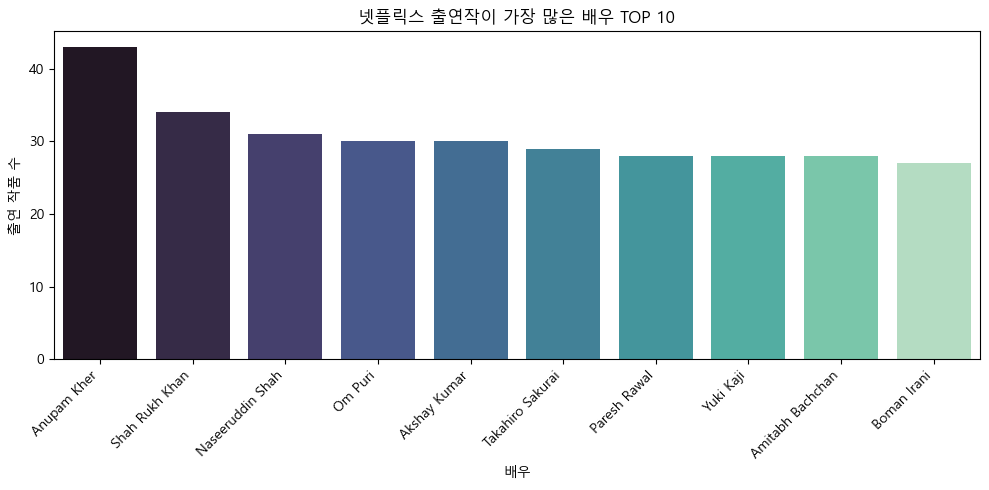

In [72]:

# 시각화
plt.figure(figsize=(10, 5))
#sns.barplot(x=top_actors.index, y=top_actors.values, palette='mako')
sns.barplot(
    data=top_actors,
    x='actor', y='count',
    hue='actor',      # <-- hue 설정
    palette='mako',
    legend=False      # <-- 범례 숨기기
)

plt.xticks(rotation=45, ha='right')
plt.title('넷플릭스 출연작이 가장 많은 배우 TOP 10')
plt.xlabel('배우')
plt.ylabel('출연 작품 수')
plt.tight_layout()
plt.show()

#### 특정 배우의 출연작 필터링 함수

In [45]:
def get_actor_titles(actor_name):
    """입력한 배우가 출연한 넷플릭스 콘텐츠 리스트 반환"""
    return netflix[netflix['cast'].str.contains(actor_name, na=False)][['title', 'type', 'release_year', 'listed_in']]

get_actor_titles('Shah Rukh Khan')

,title,type,release_year,listed_in
114,Anjaam,Movie,1994,"Dramas, International Movies, Thrillers"
301,Chennai Express,Movie,2013,"Action & Adventure, Comedies, International Mo..."
2722,Duplicate,Movie,1998,"Comedies, Dramas, International Movies"
2730,Kabhi Alvida Naa Kehna,Movie,2006,"Dramas, International Movies, Romantic Movies"
2731,Kabhi Khushi Kabhie Gham,Movie,2001,"Dramas, International Movies"
2732,Kal Ho Naa Ho,Movie,2003,"Comedies, Dramas, International Movies"
2734,Kuch Kuch Hota Hai,Movie,1998,"Comedies, Dramas, International Movies"
3133,Don,Movie,2006,"Action & Adventure, International Movies"
3134,Don 2,Movie,2011,"Action & Adventure, International Movies, Musi..."
3376,My Next Guest with David Letterman and Shah Ru...,Movie,2019,International Movies


> [분석 연습을 위한 추천 데이터셋]
> * Q1. 캐글에서 넷플릭스 데이터셋 이외에도 데이터 분석 연습을 하기 좋은 다른 데이터셋을 추천해 주세요.

> [넷플릭스 데이터셋 피처 엔지니어링]
> * Q2. 넷플릭스 데이터셋에서 어떤 추가적인 변수를 피처 엔지니어링을 통해 생성할 수 있을까요?


> [추천 시스템을 위한 변수]
> * Q3. 넷플릭스 데이터셋을 기반으로 추천 시스템을 구축하기 위해 어떤 변수를 사용할 수 있을까요?

> [수평 막대 그래프 코드]
> * Q4. 넷플릭스 데이터셋을 이용해 수평 막대 그래프를 그리는 코드를 작성해주세요.

> [사용자 집단 분석을 위한 변수]
> * Q5. 넷플릭스에서 특정 장르나 주제의 콘텐츠가 특정 사용자 집단에게 더 인기가 있는지 분석하려면 어떤 변수를 활용해야 할까요?

[넷플릭스 데이터셋의 변수 설명]

* show_id: 각 쇼의 고유 ID (쇼를 식별할 수 있는 고유한 번호)

* type: 쇼의 카테고리 (영화 또는 TV 쇼)

* title: 쇼의 이름

* director: 쇼의 감독 이름

* cast: 배우의 이름 및 쇼의 다른 출연진

* country: Netflix에서 프로그램을 시청할 수 있는 국가의 이름

* date_added: Netflix에 프로그램이 추가된 날짜

* release_year: 쇼의 출시 연도

* rating: 넷플릭스 등급 (관람 등급, 예: G, PG, TV-MA 등)

* duration: 쇼의 지속 시간 (영화는 시간, TV 쇼는 시즌 및 에피소드 수로 표현)

* listed_in: 쇼의 장르 (예: 액션, 드라마, 코미디 등)

* description: 쇼를 설명하는 일부 텍스트 (쇼의 줄거리 또는 개요)